Install packages

In [1]:
!pip install -q pandas hestia-good seaborn rdkit transformers accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 868.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 24.4 MB/s eta 0:00:00


Download ChEMBL

In [ ]:
!wget -q https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz
!tar -xzf chembl_36_sqlite.tar.gz
!ls -lh chembl_36/chembl_36_sqlite/chembl_36.db

Query HCRTR1 data

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')
query = """
SELECT cs.canonical_smiles, act.pchembl_value, act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL4822'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""
df_raw = pd.read_sql_query(query, conn)
print(df_raw.shape)
df_raw.head()

OperationalError: unable to open database file

Clean and deduplicate

In [ ]:
df_clean = df_raw.groupby('canonical_smiles')['pchembl_value'].median().reset_index()
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(df_clean.shape)
df_clean.head()

(9231, 2)


,canonical_smiles,pchembl_value
0,Br.CS(=O)(=O)N(c1cccc(C(=O)N[C@@H](Cc2ccccc2)[...,5.34
1,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,6.90
2,Brc1ccc(/C=N\C2CCN(Cc3ccccc3)C2)cc1,5.76
3,Brc1ccc(CNC2CCN(Cc3ccccc3)C2)cc1,6.19
4,C#CCCOc1cnc(C(=O)Nc2cccc([C@]3(C)CCSC(N)=N3)c2...,6.89


Load HCRTR1 data

In [ ]:
import pandas as pd

# df_clean must already be loaded from your main notebook
# Run your ChEMBL query cells first, or paste df_clean here
df = df_clean[['canonical_smiles', 'pchembl_value']].copy()
df = df.rename(columns={'canonical_smiles': 'Drug', 'pchembl_value': 'Y'})
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(9231, 2)


,Drug,Y
0,Br.CS(=O)(=O)N(c1cccc(C(=O)N[C@@H](Cc2ccccc2)[...,5.34
1,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,6.90
2,Brc1ccc(/C=N\C2CCN(Cc3ccccc3)C2)cc1,5.76
3,Brc1ccc(CNC2CCN(Cc3ccccc3)C2)cc1,6.19
4,C#CCCOc1cnc(C(=O)Nc2cccc([C@]3(C)CCSC(N)=N3)c2...,6.89


Plot distribution

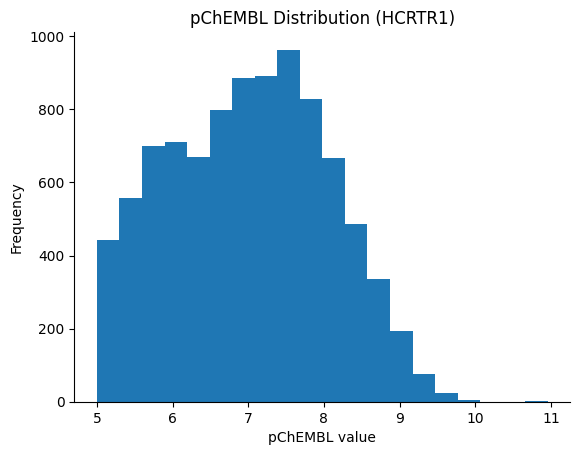

In [ ]:
from matplotlib import pyplot as plt

df['Y'].plot(kind='hist', bins=20, title='pChEMBL Distribution (HCRTR1)')
plt.xlabel('pChEMBL value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Scaffold-based split

In [ ]:
from hestia.partition import ccpart, random_partition
from hestia.similarity import molecular_similarity

sim_df = molecular_similarity(
    df_query=df,
    fingerprint='ecfp',
    radius=2,
    bits=2048,
    df=df,
    field_name='Drug',
    verbose=3
)

train, test, clusters = ccpart(
    df=df,
    sim_df=sim_df,
    test_size=0.2,
    threshold=0.4,
)
train_df = df.iloc[train, :].copy().reset_index(drop=True)
test_df  = df.iloc[test,  :].copy().reset_index(drop=True)

train, val = random_partition(train_df, test_size=0.1, random_state=42)
val_df   = train_df.iloc[val,   :].copy().reset_index(drop=True)
train_df = train_df.iloc[train, :].copy().reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Calculating molecular similarities using ecfp with 2,048 bits, radius 2 and tanimoto index...


Query FPs: 100%|██████████| 9.23k/9.23k [00:02<00:00, 3.40kit/s]
Similarity calculation: 100%|██████████| 9.23k/9.23k [00:50<00:00, 184it/s]

Plot split distributions

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 3, dpi=100)
fig.suptitle("pChEMBL distribution across splits", fontsize=14)
fig.set_size_inches(8, 3)
ax[0].hist(train_df['Y'], bins=20); ax[0].set_title('Train')
ax[1].hist(val_df['Y'],   bins=20); ax[1].set_title('Val')
ax[2].hist(test_df['Y'],  bins=20); ax[2].set_title('Test')
for i in range(3):
    ax[i].spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

Define metrics

In [ ]:
from typing import Any, Callable, List

import numpy as np
import torch
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (f1_score, matthews_corrcoef,
                             precision_recall_curve, accuracy_score,
                             mean_squared_error, mean_absolute_error,
                             roc_auc_score, auc, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
import transformers as hf


class CustomTrainer(hf.Trainer):
    def save_model(self, output_dir: str = None, _internal_call: bool = False):
        device = self.model.device
        self.model = self.model.cpu()
        super().save_model(output_dir, _internal_call)
        self.model = self.model.to(device)


class Metrics:
    multilabel = False

    def __init__(self):
        self.metrics = {}

    def add_metric(self, name: str, metric: Callable):
        self.metrics[name] = metric

    def get_metrics(self, names: List[str], multilabel: bool = False):
        metrics = Metrics()
        metrics.multilabel = multilabel
        for name in names:
            if name in self.metrics:
                metrics.add_metric(name, self.metrics[name])
            else:
                raise ValueError(f"Metric: {name} not supported.",
                                 " Please use one of the following: ",
                                 f" {list(self.metrics.keys())}")
        return metrics

    def todict(self) -> dict:
        output = {}
        for name, fun in self.metrics.items():
            output[name] = fun
        return output

    def __call__(self, eval_prediction) -> Any:
        output = {}

        preds = eval_prediction.predictions
        refs = eval_prediction.label_ids
        if isinstance(preds, tuple):
            preds = preds[0]

        if len(preds.shape) < 2:
            pass
        elif preds.shape[1] > 1 and not self.multilabel:
            preds = np.argmax(preds, axis=1)

        if preds.dtype != refs.dtype or self.multilabel:
            preds = preds > (1 / preds.shape[1])

        for key, value in self.metrics.items():
            if key == 'cm':
                output2 = value(preds, refs)
                for k2, v2 in output2.items():
                    output[k2] = v2
            else:
                output[key] = value(preds, refs)[key]
        return output


def acc(predictions, references, **kwargs):
    return {"acc": accuracy_score(references, predictions)}

def auroc(predictions, references, **kwargs):
    return {"auroc": roc_auc_score(references, predictions)}

def cm_fun(predictions, references, **kwargs):
    cm = confusion_matrix(predictions, references)
    return {'tn': cm[0, 0], 'fp': cm[0, 1], 'tp': cm[1, 1], 'fn': cm[1, 0]}

def f1_binary(predictions, references, **kwargs):
    score = f1_score(references, predictions, average='binary', zero_division=0)
    return {"f1": float(score)}

def f1_weighted(predictions, references, **kwargs):
    score = f1_score(references, predictions, average='weighted', zero_division=0)
    return {"f1_weighted": float(score)}

def mcc(predictions, references, **kwargs):
    score = matthews_corrcoef(references, predictions)
    return {"mcc": float(score)}

def spcc(predictions, references, **kwargs):
    corr, _ = spearmanr(references, predictions)
    return {"spcc": float(corr)}

def pcc(predictions, references, **kwargs):
    corr, _ = pearsonr(references, predictions)
    return {"pcc": float(corr)}

def mse(predictions, references, **kwargs):
    return {'mse': mean_squared_error(references, predictions)}

def mae(predictions, references, **kwargs):
    return {'mae': mean_absolute_error(references, predictions)}

def aupr(predictions, references, **kwargs):
    precision, recall, _ = precision_recall_curve(y_true=references, probas_pred=predictions)
    return {'aupr': auc(precision, recall)}

def cosine(predictions, references, **kwargs):
    cosine = list(map(lambda x: cosine_similarity(x[0].reshape(1, -1), x[1].reshape(1, -1)).item(), predictions))
    cosine, references = np.array(cosine), np.array(references)
    score, _ = spearmanr(references, cosine)
    return {'cos': float(score)}

def manhattan(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1), 'cityblock'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 1) + np.linalg.norm(x[1].reshape(1, -1), 1)), predictions))
    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    score, _ = spearmanr(dist, references)
    return {'manhattan': float(score)}

def euclidean(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1), 'euclidean'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 2) + np.linalg.norm(x[1].reshape(1, -1), 2)), predictions))
    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    score, _ = spearmanr(dist, references)
    return {'euclidean': float(score)}


metrics_collection = Metrics()
metrics_collection.add_metric('acc', acc)
metrics_collection.add_metric('auroc', auroc)
metrics_collection.add_metric('f1', f1_binary)
metrics_collection.add_metric('f1_weighted', f1_weighted)
metrics_collection.add_metric('mcc', mcc)
metrics_collection.add_metric('spcc', spcc)
metrics_collection.add_metric('pcc', pcc)
metrics_collection.add_metric('mse', mse)
metrics_collection.add_metric('mae', mae)
metrics_collection.add_metric('aupr', aupr)
metrics_collection.add_metric('cm', cm_fun)a qz

Configure model

In [ ]:
import copy
import transformers as hf
from datasets import Dataset

model_name = 'ibm/MoLFormer-XL-both-10pct'
num_labels = 1
metrics = ['pcc', 'spcc', 'mse', 'mae']

tokenizer = hf.AutoTokenizer.from_pretrained(
    model_name, max_length=250, trust_remote_code=True
)
model = hf.AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels, trust_remote_code=True
)

hf_args = hf.TrainingArguments(
    output_dir='molformer',
    learning_rate=1e-4,
    label_names=['labels'],
    metric_for_best_model='spcc',
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=50,
    greater_is_better=True,
    eval_accumulation_steps=1,
    load_best_model_at_end=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    report_to='tensorboard',
)

ds = {
    'train': Dataset.from_pandas(train_df),
    'val':   Dataset.from_pandas(val_df),
    'test':  Dataset.from_pandas(test_df)
}

for split in ds.keys():
    ds[split] = ds[split].map(
        lambda x: tokenizer(x['Drug'], truncation=True, padding='max_length', max_length=210)
    )
    ds[split] = ds[split].rename_column('Y', 'labels')
    ds[split] = ds[split].map(lambda x: {'labels': float(x['labels'])})
    ds[split].set_format(type='pt', columns=['input_ids', 'attention_mask', 'labels'])

trainer = CustomTrainer(
    copy.deepcopy(model),
    args=hf_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    compute_metrics=metrics_collection.get_metrics(metrics),
    callbacks=[hf.EarlyStoppingCallback(5)]
)

Train

In [ ]:
values = trainer.train()
trainer._load_best_model()

Evaluate

In [ ]:
metrics_out = trainer.evaluate(eval_dataset=ds['test'], metric_key_prefix='test')
met_df = pd.DataFrame([metrics_out])
met_df.head()